<a href="https://colab.research.google.com/github/wagmacaravan/Supervised-celltype-classification-via-pbmc-data/blob/main/supervised_celltype_classifyer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scanpy scikit-learn

In [2]:
import scanpy as sc
import numpy as np

In [3]:
adata = sc.datasets.pbmc68k_reduced()
adata

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: None (.X)

In [4]:
adata.obs['bulk_labels'].value_counts()

bulk_labels
Dendritic                       240
CD14+ Monocyte                  129
CD19+ B                          95
CD4+/CD25 T Reg                  68
CD8+ Cytotoxic T                 54
CD8+/CD45RA+ Naive Cytotoxic     43
CD56+ NK                         31
CD4+/CD45RO+ Memory              19
CD34+                            13
CD4+/CD45RA+/CD25- Naive T        8
Name: count, dtype: int64

In [5]:
adata.X.shape
adata.X[0]

array([-3.2600e-01, -1.9100e-01, -7.2800e-01, -3.0100e-01,  3.3860e+00,
       -5.3100e-01,  2.0160e+00,  3.3770e+00,  4.8410e+00, -5.2500e-01,
       -5.2500e-01,  1.8040e+00,  5.7800e-01, -1.9800e-01,  1.2660e+00,
       -1.9200e-01, -3.0700e-01,  4.8000e-02, -6.0600e-01,  4.7800e-01,
       -7.0000e-02, -8.6400e-01, -5.3400e-01, -5.0400e-01, -5.0900e-01,
       -7.2700e-01, -6.4600e-01,  3.3600e-01, -1.7000e-02,  4.3810e+00,
       -2.5100e-01,  2.3500e-01, -2.5200e-01, -7.0100e-01, -5.3700e-01,
       -6.8400e-01, -2.4400e-01, -4.2100e-01,  5.7500e-01, -3.7500e-01,
        1.5110e+00,  1.3740e+00, -5.1400e-01, -1.2000e-01,  3.4560e+00,
       -1.3000e-01, -1.4900e-01,  1.3110e+00,  2.4470e+00,  2.5490e+00,
       -4.8300e-01, -1.1200e+00, -4.9700e-01, -2.7000e-01, -1.3200e-01,
        5.8300e-01, -1.7400e-01,  9.5600e-01, -6.1000e-01, -5.7700e-01,
       -3.7500e-01, -5.3300e-01, -6.8900e-01, -2.4900e-01,  8.1100e-01,
       -4.4700e-01, -5.6500e-01, -2.4600e-01,  1.1630e+00,  3.05

In [6]:
adata.var_names[:10]

Index(['HES4', 'TNFRSF4', 'SSU72', 'PARK7', 'RBP7', 'SRM', 'MAD2L2', 'AGTRAP',
       'TNFRSF1B', 'EFHD2'],
      dtype='str', name='index')

In [7]:
adata.X[0].shape

(765,)

In [8]:
from sklearn.model_selection import train_test_split

X = adata.X
y = adata.obs['bulk_labels'].astype(str).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0,
    stratify=y,
)

print("train cells:", X_train.shape[0], "| test cells:", X_test.shape[0])

import numpy as np
rare = "CD4+/CD45RA+/CD25- Naive T"
print("rare class in train:", int((y_train == rare).sum()))
print("rare class in test: ", int((y_test == rare).sum()))

train cells: 525 | test cells: 175
rare class in train: 6
rare class in test:  2


In [9]:
int((y_test == "CD14+ Monocyte").sum())

32

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)      # this is the search — the weights get filled in
lr.coef_.shape                # the model itself: (10 classes, 765 genes)

(10, 765)

In [11]:
import numpy as np
genes = adata.var_names.to_numpy()

ci = list(lr.classes_).index("CD19+ B")
w = lr.coef_[ci]                       # 765 weights for the B-cell class
top = np.argsort(w)[::-1][:5]          # 5 largest
for t in top:
    print(genes[t], round(w[t], 3))


CD79A 0.179
CD79B 0.166
MS4A1 0.157
ACP5 0.121
BLK 0.118


In [12]:

import numpy as np
genes = adata.var_names.to_numpy()

ci = list(lr.classes_).index("CD14+ Monocyte")
w = lr.coef_[ci]                       # 765 weights
top = np.argsort(w)[::-1][:5]          # 5 largest
for t in top:
    print(genes[t], round(w[t], 3))

TMEM176A 0.2
NUP214 0.194
SRGN 0.178
SLC11A1 0.164
COX14 0.164


In [13]:
"CD14" in genes

False

In [14]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

In [15]:
#splits the model 420/105
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [16]:
models = {
    "LogReg":       LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
    "HistGB":       HistGradientBoostingClassifier(random_state=0),
}

In [17]:
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro")
    print(name, scores.round(3), "| mean", scores.mean().round(3))

LogReg [0.638 0.693 0.711 0.674 0.688] | mean 0.681
RandomForest [0.676 0.592 0.619 0.642 0.674] | mean 0.641
HistGB [0.689 0.607 0.607 0.716 0.617] | mean 0.647


In [18]:
#now train with all 525 cells now that we know LogReg is the winner
final = LogisticRegression(max_iter=2000)
final.fit(X_train, y_train)


LogisticRegression(max_iter=2000)

In [19]:
#now give the model the last sealed 175 cells but still with no labels (no answers yet)
y_pred = final.predict(X_test)

In [21]:
from sklearn.metrics import classification_report, f1_score
import numpy as np # Import numpy if not already imported, for np.round

print(classification_report(y_test, y_pred, zero_division=0))
print("test macro F1:", np.round(f1_score(y_test, y_pred, average="macro"), 3))

                              precision    recall  f1-score   support

              CD14+ Monocyte       0.88      0.94      0.91        32
                     CD19+ B       1.00      0.92      0.96        24
                       CD34+       1.00      1.00      1.00         3
             CD4+/CD25 T Reg       0.54      0.88      0.67        17
  CD4+/CD45RA+/CD25- Naive T       0.00      0.00      0.00         2
         CD4+/CD45RO+ Memory       0.00      0.00      0.00         5
                    CD56+ NK       0.86      0.75      0.80         8
            CD8+ Cytotoxic T       0.67      0.62      0.64        13
CD8+/CD45RA+ Naive Cytotoxic       0.55      0.55      0.55        11
                   Dendritic       0.96      0.92      0.94        60

                    accuracy                           0.83       175
                   macro avg       0.65      0.66      0.65       175
                weighted avg       0.82      0.83      0.82       175

test macro F1: 0.

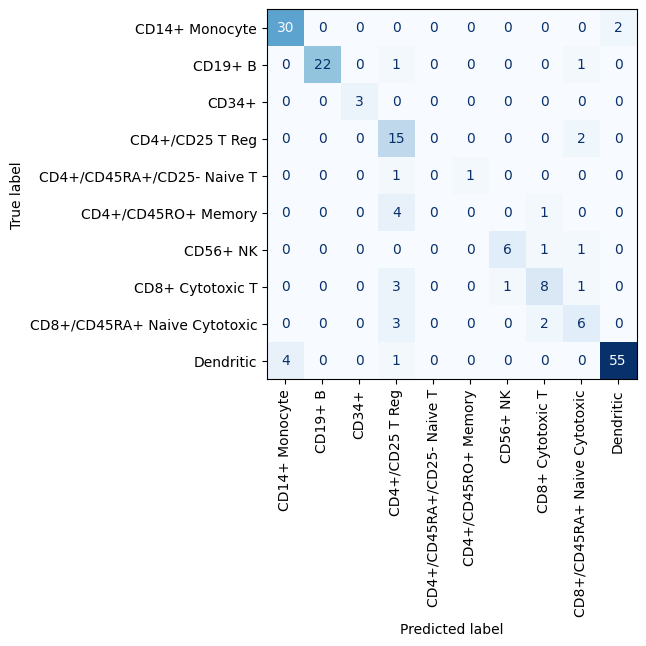

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    final, X_test, y_test, xticks_rotation=90, cmap="Blues", colorbar=False)
plt.show()